In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

In [37]:
results_df = pd.read_pickle(
    "random_portfolios.pkl"
)

In [3]:
daily_returns = pd.read_csv(
    "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

risk_return = pd.read_csv(
    "risk_return_summary.csv",
    index_col=0
)

covariance_matrix = pd.read_csv(
    "annualized_covariance_matrix.csv",
    index_col=0
)

In [4]:
expected_returns = (
    risk_return["Annualized Return (%)"].values / 100
)

cov_matrix = covariance_matrix.values

n_assets = len(expected_returns)

In [5]:
print("Number of assets:", n_assets)
print("Covariance matrix shape:", cov_matrix.shape)

Number of assets: 20
Covariance matrix shape: (20, 20)


In [6]:
constraints = [
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }
]

bounds = [
    (0, 0.25)
    for _ in range(n_assets)
]

In [7]:
def portfolio_return(weights):
    return np.dot(
        weights,
        expected_returns
    )

In [8]:
def portfolio_variance(weights):
    return (
        weights.T
        @ cov_matrix
        @ weights
    )

In [9]:
def portfolio_volatility(weights):
    return np.sqrt(
        portfolio_variance(weights)
    )

In [10]:
initial_weights = np.ones(n_assets) / n_assets

In [11]:
initial_weights.sum()

np.float64(1.0000000000000002)

In [12]:
min_variance_result = minimize(
    portfolio_variance,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [13]:
print(min_variance_result.success)

True


In [14]:
min_variance_weights = min_variance_result.x

In [15]:
min_variance_return = portfolio_return(
    min_variance_weights
)

min_variance_volatility = portfolio_volatility(
    min_variance_weights
)

In [16]:
print(
    "Minimum Variance Portfolio"
)

print(
    "Return:",
    min_variance_return * 100,
    "%"
)

print(
    "Volatility:",
    min_variance_volatility * 100,
    "%"
)

Minimum Variance Portfolio
Return: 16.544110171874475 %
Volatility: 13.623128733811157 %


In [17]:
risk_free_rate = 0.06

In [18]:
def negative_sharpe(weights):
    
    ret = portfolio_return(weights)
    
    vol = portfolio_volatility(weights)
    
    sharpe = (
        ret - risk_free_rate
    ) / vol
    
    return -sharpe

In [19]:
max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [20]:
print(max_sharpe_result.success)

True


In [21]:
max_sharpe_weights = max_sharpe_result.x

In [22]:
max_sharpe_return = portfolio_return(
    max_sharpe_weights
)

max_sharpe_volatility = portfolio_volatility(
    max_sharpe_weights
)

max_sharpe_value = (
    max_sharpe_return - risk_free_rate
) / max_sharpe_volatility

In [23]:
print("Maximum Sharpe Portfolio")
print("------------------------")

print(
    "Return:",
    max_sharpe_return * 100,
    "%"
)

print(
    "Volatility:",
    max_sharpe_volatility * 100,
    "%"
)

print(
    "Sharpe:",
    max_sharpe_value
)

Maximum Sharpe Portfolio
------------------------
Return: 22.6372363615338 %
Volatility: 16.56086925465545 %
Sharpe: 1.0046112982177482


In [24]:
target_returns = np.linspace(
    min_variance_return,
    expected_returns.max(),
    50
)

In [25]:
def negative_return(weights):
    return -portfolio_return(weights)

In [26]:
max_return_result = minimize(
    negative_return,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [27]:
maximum_feasible_return = portfolio_return(
    max_return_result.x
)

In [28]:
target_returns = np.linspace(
    min_variance_return,
    maximum_feasible_return,
    50
)

In [29]:
def minimize_volatility_for_target_return(
    target_return
):
    
    constraints_target = [
        {
            "type": "eq",
            "fun": lambda weights:
                np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights:
                portfolio_return(weights)
                - target_return
        }
    ]
    
    result = minimize(
        portfolio_variance,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints_target
    )
    
    if result.success:
        volatility = portfolio_volatility(
            result.x
        )
        
        return volatility, result.x
    
    return np.nan, None

In [30]:
frontier_volatility = []
frontier_weights = []

for target in target_returns:
    
    volatility, weights = (
        minimize_volatility_for_target_return(
            target
        )
    )
    
    frontier_volatility.append(
        volatility
    )
    
    frontier_weights.append(
        weights
    )

In [31]:
frontier_volatility = np.array(
    frontier_volatility
)

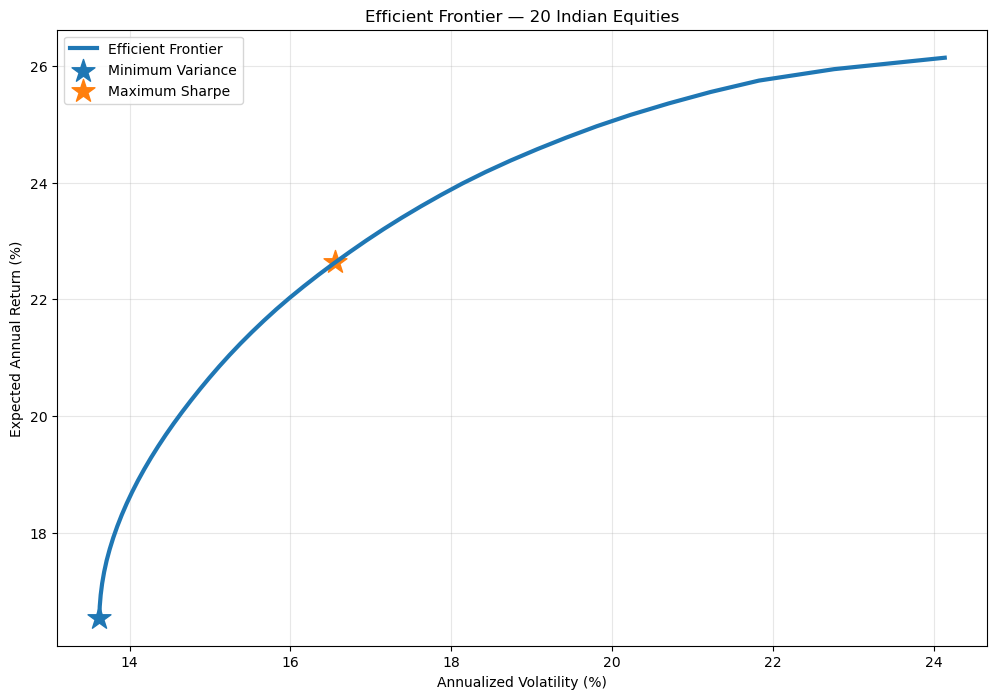

In [33]:
plt.figure(figsize=(12, 8))

plt.plot(
    frontier_volatility * 100,
    target_returns * 100,
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    min_variance_volatility * 100,
    min_variance_return * 100,
    marker="*",
    s=300,
    label="Minimum Variance"
)

plt.scatter(
    max_sharpe_volatility * 100,
    max_sharpe_return * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.xlabel(
    "Annualized Volatility (%)"
)

plt.ylabel(
    "Expected Annual Return (%)"
)

plt.title(
    "Efficient Frontier — 20 Indian Equities"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

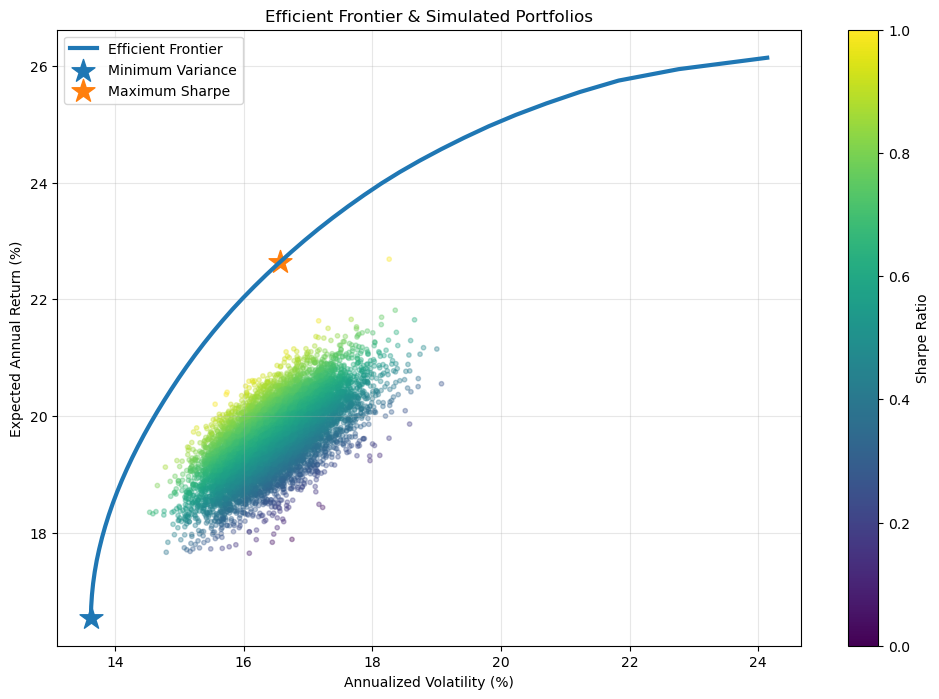

In [38]:
plt.figure(figsize=(12, 8))

plt.scatter(
    results_df["Volatility"] * 100,
    results_df["Return"] * 100,
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.35,
    s=10
)

plt.plot(
    frontier_volatility * 100,
    target_returns * 100,
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    min_variance_volatility * 100,
    min_variance_return * 100,
    marker="*",
    s=300,
    label="Minimum Variance"
)

plt.scatter(
    max_sharpe_volatility * 100,
    max_sharpe_return * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.xlabel(
    "Annualized Volatility (%)"
)

plt.ylabel(
    "Expected Annual Return (%)"
)

plt.title(
    "Efficient Frontier & Simulated Portfolios"
)

plt.colorbar(
    label="Sharpe Ratio"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [39]:
equal_weights = np.ones(n_assets) / n_assets

equal_return = portfolio_return(
    equal_weights
)

equal_volatility = portfolio_volatility(
    equal_weights
)

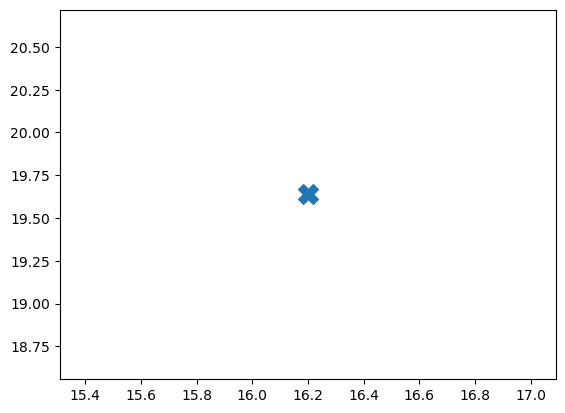

In [40]:
plt.scatter(
    equal_volatility * 100,
    equal_return * 100,
    marker="X",
    s=200,
    label="Equal Weight"
)

In [41]:
weights_table = pd.DataFrame({
    "Minimum Variance": min_variance_weights,
    "Maximum Sharpe": max_sharpe_weights,
    "Equal Weight": equal_weights
}, index=daily_returns.columns)

In [42]:
weights_table

,Minimum Variance,Maximum Sharpe,Equal Weight
ASIANPAINT.NS,8.070003e-02,2.622899e-02,0.05
BHARTIARTL.NS,4.920305e-02,1.716278e-01,0.05
HDFCBANK.NS,1.195586e-01,1.058732e-02,0.05
HINDALCO.NS,1.094688e-18,8.123322e-03,0.05
HINDUNILVR.NS,1.705294e-01,7.846116e-02,0.05
ICICIBANK.NS,7.389409e-19,1.449764e-17,0.05
INFY.NS,4.309464e-02,1.089767e-01,0.05
ITC.NS,1.113993e-01,3.414197e-17,0.05
KOTAKBANK.NS,9.131831e-03,0.000000e+00,0.05
LT.NS,2.568173e-18,1.587058e-17,0.05


In [43]:
print(
    "Min variance weight sum:",
    min_variance_weights.sum()
)

print(
    "Max Sharpe weight sum:",
    max_sharpe_weights.sum()
)

Min variance weight sum: 1.0
Max Sharpe weight sum: 0.9999999999551934


In [44]:
print(
    "Maximum Min-Variance weight:",
    min_variance_weights.max()
)

print(
    "Maximum Max-Sharpe weight:",
    max_sharpe_weights.max()
)

Maximum Min-Variance weight: 0.1705293746549076
Maximum Max-Sharpe weight: 0.22730878489787812


In [46]:
weights_table.to_csv(
    "optimized_portfolio_weights.csv"
)

In [47]:
frontier_df = pd.DataFrame({
    "Target Return": target_returns,
    "Volatility": frontier_volatility
})

In [48]:
frontier_df.to_csv(
    "efficient_frontier.csv",
    index=False
)